In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from collections import defaultdict
from nltk.sentiment.vader import SentimentIntensityAnalyzer 



In [2]:

# Define output directory for visualizations
output_visualization_dir = "/home/krishantha/Github/fyp-l4/data/visualizations"  # Or your preferred path
os.makedirs(output_visualization_dir, exist_ok=True)

# Load the dataset
try:
    df = pd.read_csv("/home/krishantha/Github/fyp-l4/data/processed_data/cleaned_merged_user_post_data.csv")  # Or your cleaned data path
    print("Data loaded successfully!")
except FileNotFoundError:
    print("Error: Data file not found. Make sure to run the data processing script first.")
    exit() # Exit if data file not found

# Convert timestamp to datetime objects for time-based visualizations
df['datetime'] = pd.to_datetime(df['timestamp'], unit='s')
df['day_of_week'] = df['datetime'].dt.dayofweek  # 0=Monday, 6=Sunday
df['hour_of_day'] = df['datetime'].dt.hour



Data loaded successfully!


Visualizations

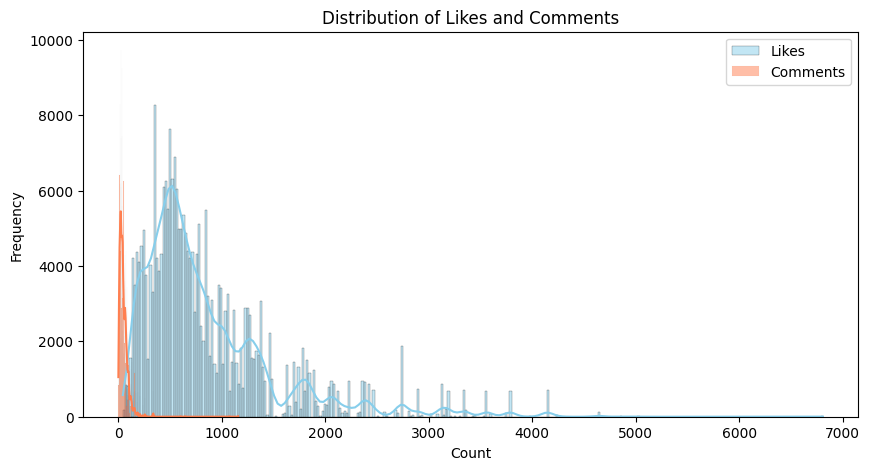

In [3]:

# --- Visualizations ---

# 1. Distribution of Likes and Comments:
plt.figure(figsize=(10, 5))
sns.histplot(df['likes'], kde=True, label='Likes', color='skyblue')
sns.histplot(df['comments_count'], kde=True, label='Comments', color='coral')
plt.title('Distribution of Likes and Comments')
plt.xlabel('Count')
plt.ylabel('Frequency')
plt.legend()
plt.savefig(os.path.join(output_visualization_dir, "likes_comments_distribution.png"))
plt.show()  # Essential for displaying plots in Jupyter Notebook



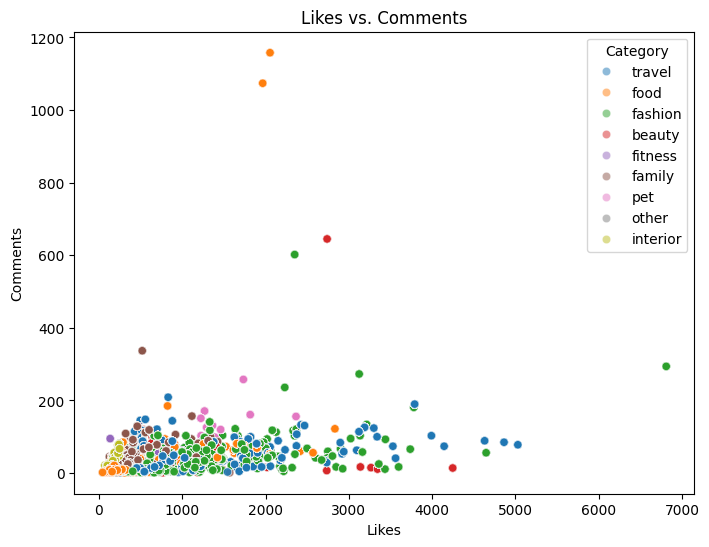

In [4]:


# 2. Likes vs. Comments Scatter Plot:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='likes', y='comments_count', data=df, hue='Category', alpha=0.5)
plt.title('Likes vs. Comments')
plt.xlabel('Likes')
plt.ylabel('Comments')
plt.savefig(os.path.join(output_visualization_dir, "likes_vs_comments.png"))
plt.show()


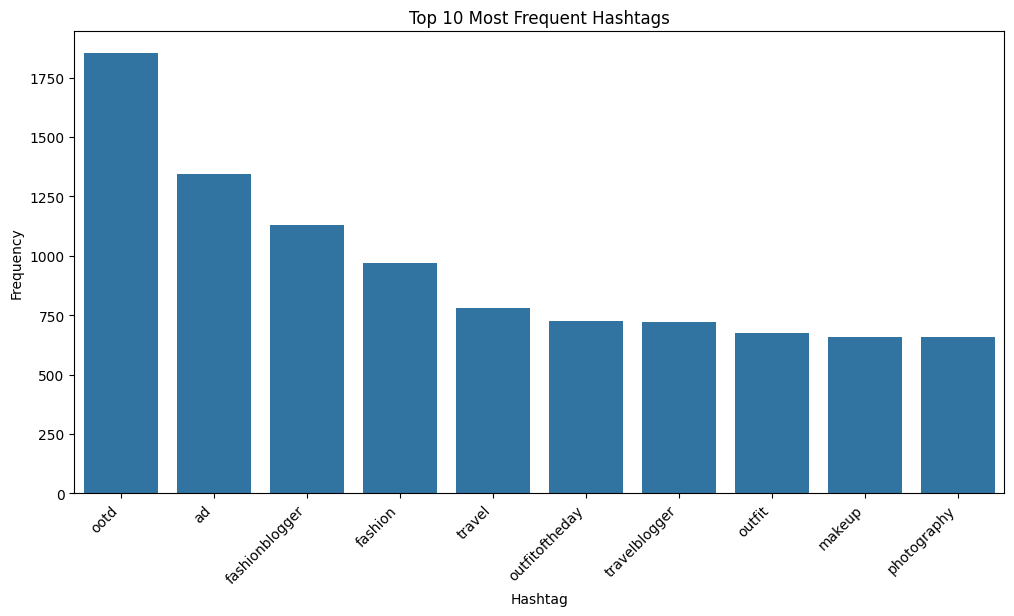

In [5]:

# 3. Top Hashtags:
top_hashtags = df['hashtags'].str.split(expand=True).stack().value_counts().nlargest(10)  # Correct hashtag splitting
plt.figure(figsize=(12, 6))
sns.barplot(x=top_hashtags.index, y=top_hashtags.values)
plt.title('Top 10 Most Frequent Hashtags')
plt.xlabel('Hashtag')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels
plt.savefig(os.path.join(output_visualization_dir, "top_hashtags.png"))
plt.show()



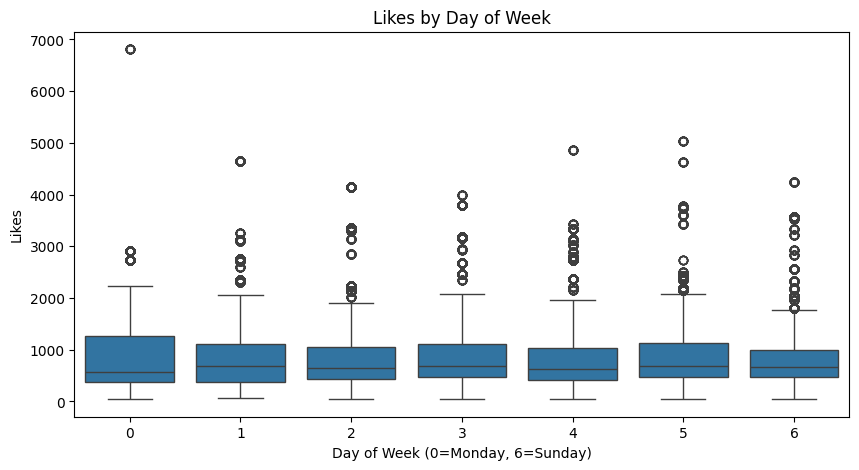

In [6]:

# 4. Engagement Over Time:
# Likes by Day of Week:
plt.figure(figsize=(10, 5))
sns.boxplot(x='day_of_week', y='likes', data=df)
plt.title('Likes by Day of Week')
plt.xlabel('Day of Week (0=Monday, 6=Sunday)')
plt.ylabel('Likes')
plt.savefig(os.path.join(output_visualization_dir, "likes_by_day.png"))
plt.show()



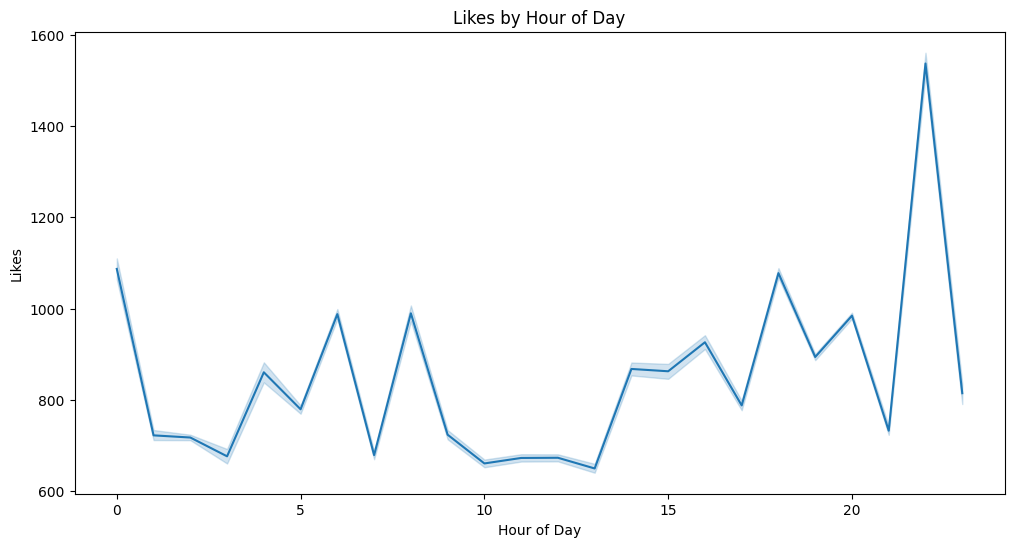

In [7]:

# Likes by Hour of Day
plt.figure(figsize=(12, 6))
sns.lineplot(x='hour_of_day', y='likes', data=df)
plt.title('Likes by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Likes')
plt.savefig(os.path.join(output_visualization_dir, "likes_by_hour.png"))
plt.show()


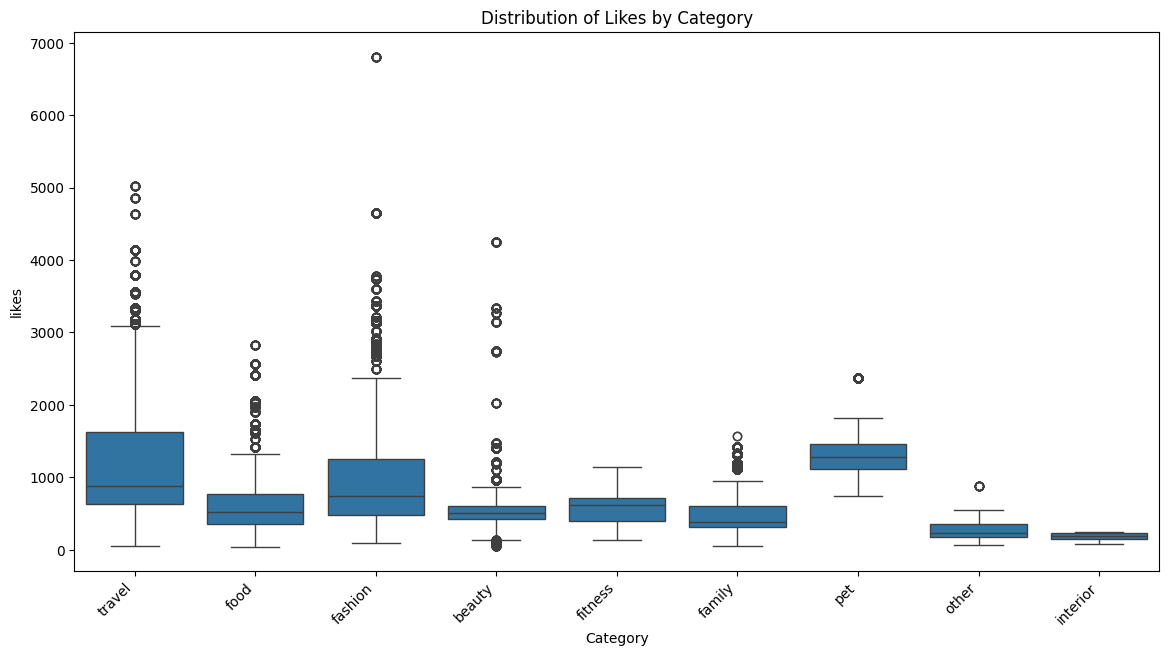

In [8]:


# 5. Category-Specific Analysis:
# Distribution of Likes for each category:
plt.figure(figsize=(14, 7))
sns.boxplot(x='Category', y='likes', data=df)  # Use boxplot for distribution
plt.title('Distribution of Likes by Category')
plt.xticks(rotation=45, ha='right')
plt.savefig(os.path.join(output_visualization_dir, "likes_by_category.png"))
plt.show()




#Engagement Metrics

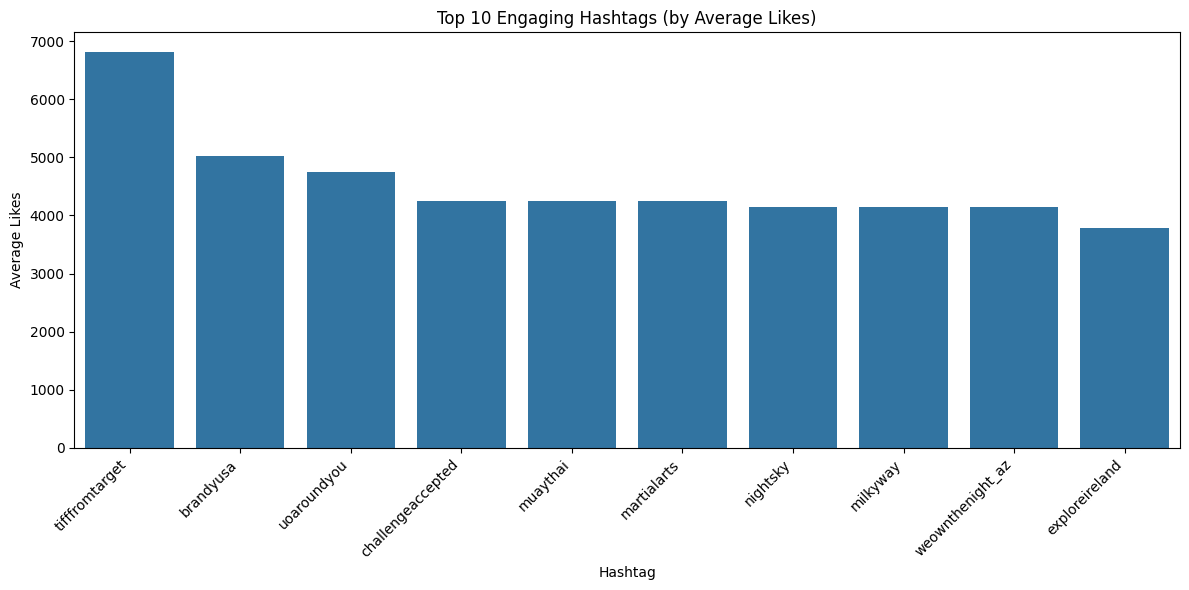

In [9]:

# 1. Hashtag Engagement Analysis:
hashtag_engagement = defaultdict(list)
for index, row in df.iterrows():
    for hashtag in row['hashtags'].split(','):
        hashtag_engagement[hashtag.strip().lower()].append(row['likes']) # Consider likes as your engagement metric

hashtag_engagement_df = pd.DataFrame([(hashtag, likes) for hashtag, likes_list in hashtag_engagement.items() for likes in likes_list],
                                  columns = ['hashtag', 'likes'])

top_engaging_hashtags = hashtag_engagement_df.groupby('hashtag')['likes'].mean().sort_values(ascending=False).head(10)


plt.figure(figsize=(12, 6))
sns.barplot(x=top_engaging_hashtags.index, y=top_engaging_hashtags.values)
plt.title('Top 10 Engaging Hashtags (by Average Likes)')
plt.xlabel('Hashtag')
plt.ylabel('Average Likes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.savefig(os.path.join(output_visualization_dir, "top_engaging_hashtags.png"))
plt.show()



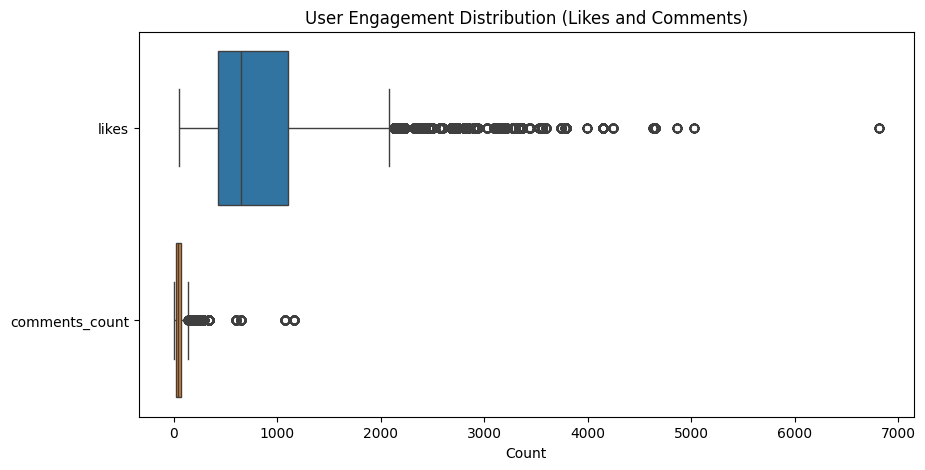

In [10]:

# 2. User Engagement Distribution (Likes, Comments):
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[['likes', 'comments_count']], orient='h') # Combined distribution plot
plt.title('User Engagement Distribution (Likes and Comments)')
plt.xlabel('Count')
plt.savefig(os.path.join(output_visualization_dir, 'user_engagement_distribution.png'))
plt.show()

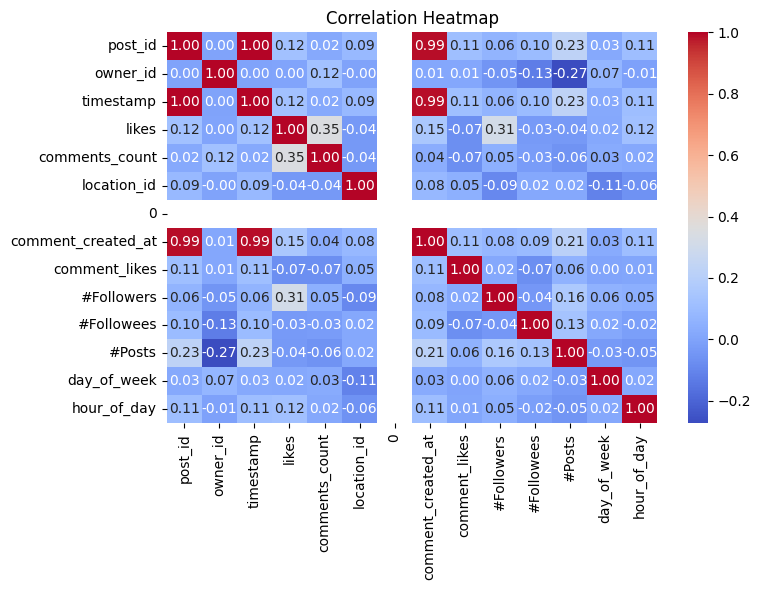

In [11]:
# 3.  Correlation Heatmap (Likes, Comments, Followers):

# Calculate correlation only on numerical columns that exist
numerical_cols = df.select_dtypes(include=['number']).columns
correlation_matrix = df[numerical_cols].corr()


plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f") # fmt = ".2f" formats correlation values to 2 decimal places.
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig(os.path.join(output_visualization_dir, 'correlation_heatmap.png'))
plt.show()


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /home/krishantha/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


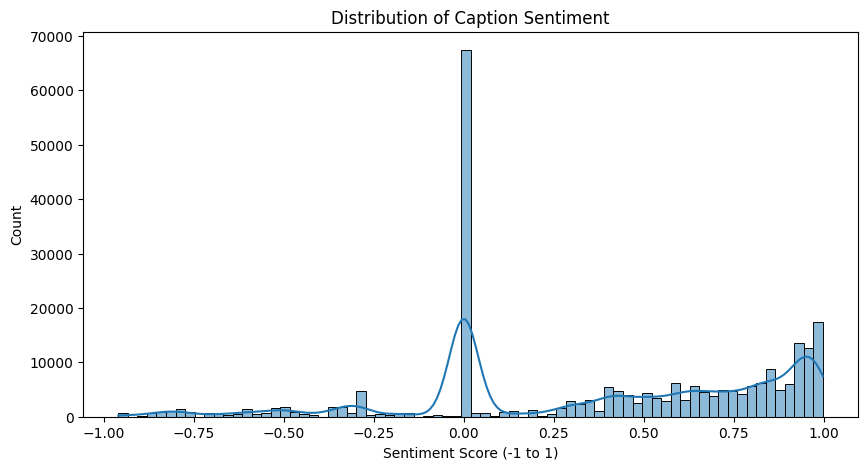

In [12]:

# 4.  Sentiment Analysis of Captions (Module 2 crossover - requires NLTK):
# Download VADER lexicon if you haven't already:
import nltk

try:
    nltk.data.find('vader_lexicon')
except LookupError:
    nltk.download('vader_lexicon')

analyzer = SentimentIntensityAnalyzer()

# Handle NaN values and ensure captions are strings before sentiment analysis
df['caption'] = df['caption'].astype(str)  # Convert the entire column to strings
df['caption_sentiment'] = df['caption'].apply(
    lambda x: analyzer.polarity_scores(x)['compound'] if isinstance(x, str) else None  # Check type and handle NaN appropriately. If not a string - None is assigned. If a string and an error occurs during sentiment analysis - then the script crashes, showing the error and type of x.
)


plt.figure(figsize=(10, 5))
sns.histplot(df['caption_sentiment'].dropna(), kde=True)  # Remove NaN values for plotting
plt.title('Distribution of Caption Sentiment')
plt.xlabel('Sentiment Score (-1 to 1)')
plt.savefig(os.path.join(output_visualization_dir, 'caption_sentiment_distribution.png'))
plt.show()


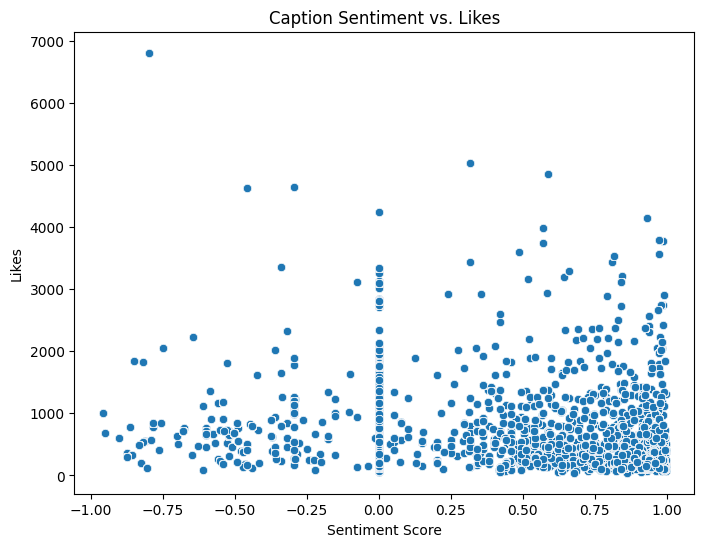


--- Suggestions for Maximizing Post Popularity ---
Average likes per post: 862.36

High-performing hashtags (above average likes):
hashtag
100senses     2742.000000
100均          1076.914286
2              977.000000
2019          1542.500000
26birthday    1310.000000
                 ...     
선물추천          1209.000000
체인핸드크림        1209.000000
탬버린즈          1209.000000
핸드크림          1209.000000
핸드크림추천        1209.000000
Name: likes, Length: 1839, dtype: float64


In [13]:

# 5.  Sentiment vs. Likes:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='caption_sentiment', y='likes', data=df)
plt.title('Caption Sentiment vs. Likes')
plt.xlabel('Sentiment Score')
plt.ylabel('Likes')
plt.savefig(os.path.join(output_visualization_dir, 'sentiment_vs_likes.png'))
plt.show()
# ---  Suggestions for Maximizing Popularity ---
print("\n--- Suggestions for Maximizing Post Popularity ---")


# Example (using likes as a simple popularity measure):
average_likes = df['likes'].mean()
print(f"Average likes per post: {average_likes:.2f}")

# Find high-performing hashtags
high_performing_hashtags = hashtag_engagement_df.groupby('hashtag')['likes'].mean()[hashtag_engagement_df.groupby('hashtag')['likes'].mean() > average_likes] # hashtags with higher than average likes.


print(f"\nHigh-performing hashtags (above average likes):\n{high_performing_hashtags}")


In [14]:

# ---  Suggestions for Maximizing Popularity ---
print("\n--- Suggestions for Maximizing Post Popularity ---")


# Example (using likes as a simple popularity measure):
average_likes = df['likes'].mean()
print(f"Average likes per post: {average_likes:.2f}")

# Find high-performing hashtags
high_performing_hashtags = hashtag_engagement_df.groupby('hashtag')['likes'].mean()[hashtag_engagement_df.groupby('hashtag')['likes'].mean() > average_likes] # hashtags with higher than average likes.


print(f"\nHigh-performing hashtags (above average likes):\n{high_performing_hashtags}")



--- Suggestions for Maximizing Post Popularity ---
Average likes per post: 862.36

High-performing hashtags (above average likes):
hashtag
100senses     2742.000000
100均          1076.914286
2              977.000000
2019          1542.500000
26birthday    1310.000000
                 ...     
선물추천          1209.000000
체인핸드크림        1209.000000
탬버린즈          1209.000000
핸드크림          1209.000000
핸드크림추천        1209.000000
Name: likes, Length: 1839, dtype: float64


#User-Specific Engagement

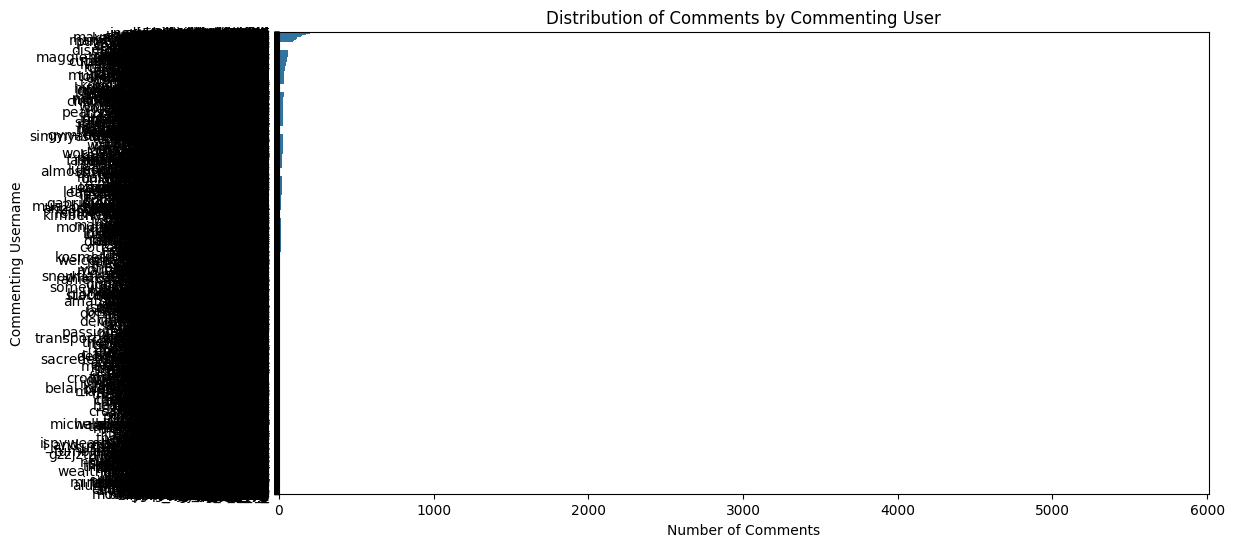

In [16]:
# 1. Commenting User Category Distribution:
plt.figure(figsize=(12, 6))
sns.countplot(y=df['comment_owner_username'], order=df['comment_owner_username'].value_counts().index)
plt.title('Distribution of Comments by Commenting User')
plt.xlabel('Number of Comments')
plt.ylabel('Commenting Username')
plt.savefig(os.path.join(output_visualization_dir, 'comment_user_distribution.png'))
plt.show()

In [ ]:

# 2. Commenting User vs. Post Owner (Heatmap):
comment_owner_interaction = pd.crosstab(df['comment_owner_username'], df['username'])


plt.figure(figsize=(10, 8))
sns.heatmap(comment_owner_interaction, cmap="YlGnBu", annot=True, fmt="d")
plt.title('Commenting User vs. Post Owner Interaction')
plt.xlabel('Post Owner (username)')
plt.ylabel('Commenting User')
plt.tight_layout()
plt.savefig(os.path.join(output_visualization_dir, 'user_interaction_heatmap.png'))
plt.show()


In [ ]:

# 3. Commenting User Profiles (Top N Commenters):

top_commenters = df['comment_owner_username'].value_counts().nlargest(10).index  # Get top 10 commenters
top_commenters_df = df[df['comment_owner_username'].isin(top_commenters)]



# Example profile visualization (Likes distribution for top commenters):
plt.figure(figsize=(12, 6))
sns.boxplot(x='comment_owner_username', y='likes', data=top_commenters_df)
plt.title('Likes Distribution for Top 10 Commenters')
plt.xlabel('Commenting User')
plt.ylabel('Likes')
plt.xticks(rotation=45, ha='right')
plt.savefig(os.path.join(output_visualization_dir, 'top_commenters_likes.png'))
plt.show()



In [ ]:

# Example: distribution of comment sentiment of top commenters

# Assuming you already have a 'comment_sentiment' column
# (from a sentiment analysis of the comments) - similar to caption sentiment
# If you don't, see the previous examples for how to calculate this.
if 'comment_text' in df.columns: # Check column exists before using.
    try:
        nltk.data.find('vader_lexicon')
    except LookupError:
        nltk.download('vader_lexicon')

    analyzer = SentimentIntensityAnalyzer()
    df['comment_sentiment'] = df['comment_text'].astype(str).apply(lambda x: analyzer.polarity_scores(str(x))['compound'])
    
    
    plt.figure(figsize=(12, 6))
    sns.boxplot(x='comment_owner_username', y='comment_sentiment', data=top_commenters_df)
    plt.title('Comment Sentiment Distribution for Top 10 Commenters')
    plt.xlabel('Commenting User')
    plt.ylabel('Average Comment Sentiment')
    plt.xticks(rotation=45, ha='right')
    plt.savefig(os.path.join(output_visualization_dir, 'top_commenters_sentiment.png'))
    plt.show()

In [15]:

print(f"Visualizations saved to: {output_visualization_dir}")

Visualizations saved to: /home/krishantha/Github/fyp-l4/data/visualizations
